## 1 A/B testing

In [189]:
import numpy as np
from datascience import *
import matplotlib.pyplot as plots
%matplotlib inline
plots.style.use('fivethirtyeight')

In [190]:
births = Table().read_table('../../Data/baby.csv')
births

Unnamed: 0,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight,Maternal.Smoker
1,120,284,27,62,100,False
2,113,282,33,64,135,False
3,128,279,28,64,115,True
4,108,282,23,67,125,True
5,136,286,25,62,93,False
6,138,244,33,62,178,False
7,132,245,23,65,140,False
8,120,289,25,62,125,False
9,143,299,30,66,136,True
10,140,351,27,68,120,False


In [191]:
birth_weight_smoke = births.select('Birth.Weight', 'Maternal.Smoker')
birth_weight_smoke

Birth.Weight,Maternal.Smoker
120,False
113,False
128,True
108,True
136,False
138,False
132,False
120,False
143,True
140,False


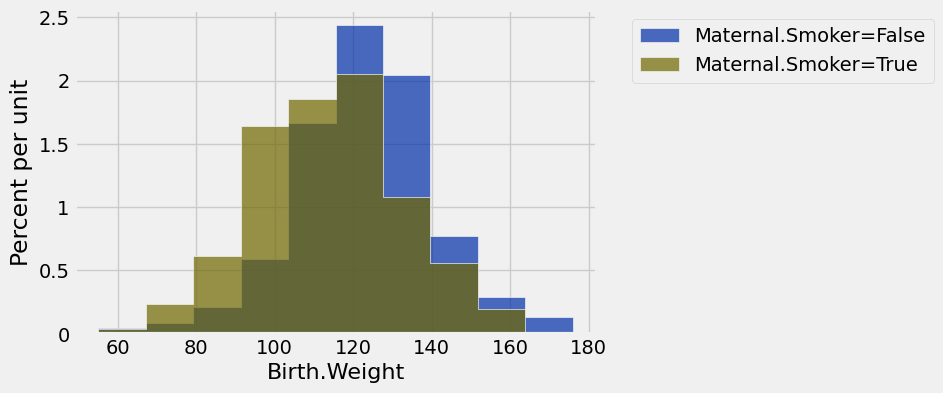

In [192]:
birth_weight_smoke.hist('Birth.Weight', group = 'Maternal.Smoker')

Mo phong thu phep thu hoan vi doi voi hai cot tren

In [193]:
def different_value(table, group_column):
    avg_table = table.group(group_column, np.average)
    mean = avg_table.column(1)
    return mean.item(1) - mean.item(0)

def one_simulated():
    Shuffle_value = birth_weight_smoke.sample(with_replacement= False).column(1)
    table = birth_weight_smoke.with_column('Shuffle_label', Shuffle_value)
    table1 = table.select('Birth.Weight','Shuffle_label')
    return different_value(table1,'Shuffle_label')


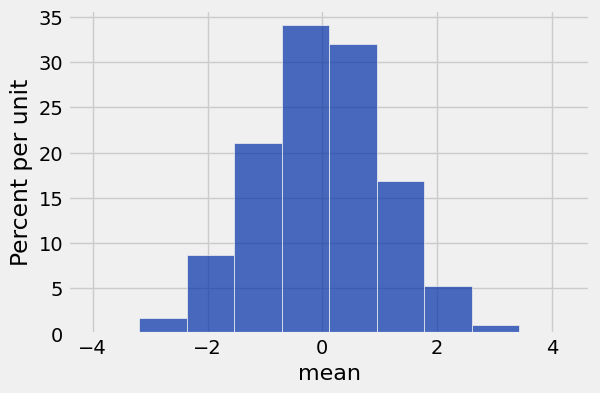

In [194]:
repition = 5000
result = make_array()
for i in np.arange(repition):
    value = one_simulated()
    result = np.append(result,value)

result1 = Table().with_column(
    'mean',result
)
result1.hist()

## 2. Mo ta mot thi nghiem dau lung: mot thu nghiem doi chung ngau nhien 

In [195]:
bta =  Table.read_table('../../Data/bta.csv')
bta

Group,Result
Control,1
Control,1
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0


In [196]:
bta.group('Group',np.sum)

Group,Result sum
Control,2
Treatment,9


In [197]:
mean = bta.group('Group',np.average)

In [198]:
observed = mean.column(1)
observed_value = observed.item(1) - observed.item(0)
observed_value

0.475

In [199]:
def different_value1(table,group_method):
    mean = table.group(group_method,np.average)
    mean1 = mean.column(1)
    return abs(mean1.item(0) - mean1.item(1))
def one_simulated1():
    permutation1 = bta.sample(with_replacement= False).column(0)
    tab1 = bta.with_column('shuffle_value',permutation1)
    tab2 = tab1.select('shuffle_value','Result')
    return different_value1(tab2,'shuffle_value')


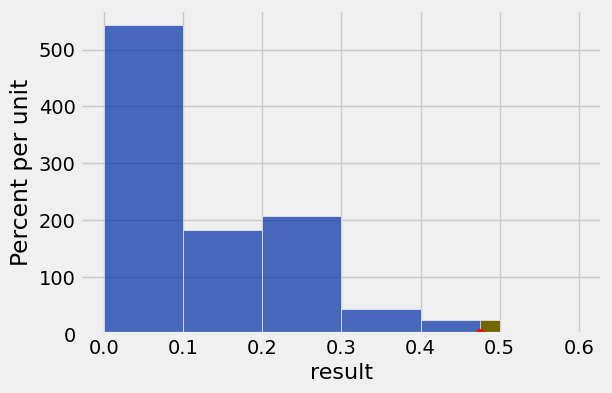

In [200]:
repition = 20000
result = make_array()

for i in np.arange(repition):
    value = one_simulated1()
    result = np.append(result,value)
Table().with_column('result', result).hist(
    bins = np.arange(0, 0.7, 0.1), left_end = observed_value)
plots.scatter(observed_value,0,color = 'red', s= 50)

In [201]:
np.count_nonzero(result >= observed_value)/repition * 100 

0.92999999999999994

=> ung ho gia thuyet thay the

Xay dung vu be boi delflategate

In [202]:
football = Table.read_table('../../Data/deflategate.csv')
football

Team,Blakeman,Prioleau
Patriots,11.5,11.8
Patriots,10.85,11.2
Patriots,11.15,11.5
Patriots,10.7,11
Patriots,11.1,11.45
Patriots,11.6,11.95
Patriots,11.85,12.3
Patriots,11.1,11.55
Patriots,10.95,11.35
Patriots,10.5,10.9


In [203]:
football = football.with_column(
    'Combine', (football.column(1) + football.column(2))/2
).drop(1,2)
football.show(15)

Team,Combine
Patriots,11.65
Patriots,11.025
Patriots,11.325
Patriots,10.85
Patriots,11.275
Patriots,11.775
Patriots,12.075
Patriots,11.325
Patriots,11.15
Patriots,10.7


In [204]:
array1 = 12.5 * np.ones(11)
array2 = 13*np.ones(4)
football_start = np.append(array1,array2)
football_start

array([ 12.5,  12.5,  12.5,  12.5,  12.5,  12.5,  12.5,  12.5,  12.5,
        12.5,  12.5,  13. ,  13. ,  13. ,  13. ])

In [205]:
football = football.with_column(
    'Muc_giam_ap_suat', football_start -football.column('Combine')
).drop(1)
football.show(15)

Team,Muc_giam_ap_suat
Patriots,0.85
Patriots,1.475
Patriots,1.175
Patriots,1.65
Patriots,1.225
Patriots,0.725
Patriots,0.425
Patriots,1.175
Patriots,1.35
Patriots,1.8


In [206]:
means = football.group('Team', np.average).column(1)
observed_different = means.item(1) - means.item(0)
observed_different

0.733522727272728

In [207]:
def different_value2(table, groups):
    meanss_table = table.group(groups,np.average)
    meanss = meanss_table.column(1)
    return meanss.item(1) - meanss.item(0)

def one_simulated2():
    shuffled = football.sample(with_replacement=False).column('Team')
    table = football.with_column('shuffle_value',shuffled).select('Muc_giam_ap_suat','shuffle_value')
    return different_value2(table,'shuffle_value')
one_simulated2()

-0.050568181818182456

Observed Difference: 0.733522727272728


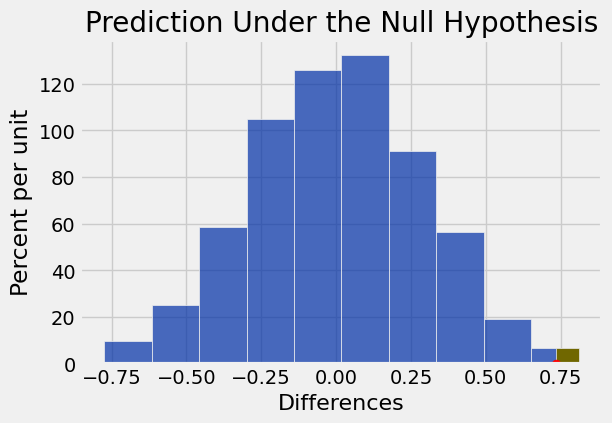

In [208]:
repition = 10000
differents = make_array()
for i in np.arange(repition):
    value = one_simulated2()
    differents = np.append(differents,value)

result = Table().with_column(
    'Differences',differents
)
result.hist(left_end= observed_different)
plots.scatter(observed_different,0,color = 'red',s = 40)
plots.title('Prediction Under the Null Hypothesis')
print('Observed Difference:', observed_different)

In [209]:
np.count_nonzero(differents >= observed_different)/repition*100

0.27000000000000002